# The Gender Conversion Gap: Report Figures

This notebook creates report-ready figures for the final analytical report.

The figures use processed datasets created in the feasibility, EDA, and hypothesis-testing notebooks. The goal is to keep all report visuals in one place, with one visual style and one colorblind-friendly palette.

## Figure plan

The report needs visuals that support three jobs:

1. Show that the data are curated and usable.
2. Explain Estonia's position relative to the OECD-member sample.
3. Summarize what the hypothesis tests do and do not support.

All charts use the OECD-member country sample and exclude aggregate areas unless stated otherwise.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Project paths
PROJECT_PATH = Path("/Users/avr/Jupiter/Gender Inequality Report - startisctic capstone")
DATA_PATH = PROJECT_PATH / "data" / "processed"
FIGURE_PATH = PROJECT_PATH / "reports" / "figures"
TABLE_PATH = PROJECT_PATH / "reports" / "tables"

FIGURE_PATH.mkdir(parents=True, exist_ok=True)
TABLE_PATH.mkdir(parents=True, exist_ok=True)
FIGURE_PATH

PosixPath('/Users/avr/Jupiter/Gender Inequality Report - startisctic capstone/reports/figures')

In [3]:
# Load processed datasets from previous notebooks.
df = pd.read_csv(DATA_PATH / "gender_conversion_gap_latest.csv")
data_dict = pd.read_csv(DATA_PATH / "data_dictionary.csv")
indicator_coverage = pd.read_csv(DATA_PATH / "indicator_coverage.csv")
estonia_benchmark = pd.read_csv(DATA_PATH / "estonia_benchmark_oecd.csv")
hypothesis_results = pd.read_csv(DATA_PATH / "hypothesis_test_results_oecd.csv")
hypothesis_summary = pd.read_csv(DATA_PATH / "hypothesis_results_summary_oecd.csv")
pairwise_samples = pd.read_csv(DATA_PATH / "pairwise_testing_samples_oecd.csv")

h1_sample = pd.read_csv(DATA_PATH / "h1_pairwise_oecd_sample.csv")
h2_sample = pd.read_csv(DATA_PATH / "h2_pairwise_oecd_sample.csv")
h3_sample = pd.read_csv(DATA_PATH / "h3_pairwise_oecd_sample.csv")
h4_sample = pd.read_csv(DATA_PATH / "h4_pairwise_oecd_sample.csv")

df_main = df[(df["is_oecd_member"]) & (~df["is_aggregate_area"])].copy()

print(f"Main OECD-member sample: {df_main.shape[0]} countries")
print(f"Figures will be saved to: {FIGURE_PATH}")
print(f"Tables will be saved to: {TABLE_PATH}")

Main OECD-member sample: 38 countries
Figures will be saved to: /Users/avr/Jupiter/Gender Inequality Report - startisctic capstone/reports/figures
Tables will be saved to: /Users/avr/Jupiter/Gender Inequality Report - startisctic capstone/reports/tables


In [4]:
# Core indicator order used across all report figures.
indicator_order = [
    "stem_women_share",
    "coding_gap_youth_M_minus_F",
    "labour_force_participation_gap_M_minus_F",
    "gender_wage_gap_median",
    "part_time_employment_gap_F_minus_M",
    "women_senior_middle_mgmt_share",
]

indicator_labels = {
    "stem_women_share": "Women among tertiary\nSTEM graduates",
    "coding_gap_youth_M_minus_F": "Youth coding gap\n(M - F)",
    "labour_force_participation_gap_M_minus_F": "Labour-force participation\ngap (M - F)",
    "gender_wage_gap_median": "Median gender\nwage gap",
    "part_time_employment_gap_F_minus_M": "Part-time employment\ngap (F - M)",
    "women_senior_middle_mgmt_share": "Women in senior/middle\nmanagement",
}

short_indicator_labels = {
    "stem_women_share": "Women in STEM graduates",
    "coding_gap_youth_M_minus_F": "Youth coding gap",
    "labour_force_participation_gap_M_minus_F": "Labour-force participation gap",
    "gender_wage_gap_median": "Median gender wage gap",
    "part_time_employment_gap_F_minus_M": "Part-time employment gap",
    "women_senior_middle_mgmt_share": "Women in senior/middle management",
}

axis_labels = {
    "stem_women_share": "Women among tertiary STEM graduates (%)",
    "coding_gap_youth_M_minus_F": "Youth coding gap, male minus female (pp)",
    "labour_force_participation_gap_M_minus_F": "Labour-force participation gap, male minus female (pp)",
    "gender_wage_gap_median": "Median gender wage gap indicator (%)",
    "part_time_employment_gap_F_minus_M": "Part-time employment gap, female minus male (pp)",
    "women_senior_middle_mgmt_share": "Women in senior/middle management (%)",
}

hypothesis_labels = {
    "H1": "H1: STEM -> leadership",
    "H2": "H2: STEM -> pay equality",
    "H3": "H3: coding gap -> labour-force gap",
    "H4": "H4: part-time gap -> wage gap",
}

In [5]:
# Colorblind-friendly palette based on Okabe-Ito colors.
COLORS = {
    "blue": "#0072B2",
    "sky": "#56B4E9",
    "green": "#009E73",
    "yellow": "#F0E442",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "black": "#111111",
    "dark_grey": "#4D4D4D",
    "mid_grey": "#8A8A8A",
    "light_grey": "#D9D9D9",
    "very_light_grey": "#F4F4F4",
    "white": "#FFFFFF",
}

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": COLORS["dark_grey"],
    "axes.labelcolor": COLORS["black"],
    "xtick.color": COLORS["dark_grey"],
    "ytick.color": COLORS["dark_grey"],
    "text.color": COLORS["black"],
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.8,
})

saved_figures = []
saved_tables = []


def clean_axes(ax, *, grid_axis="x"):
    # Apply a quiet report style to a matplotlib axis.
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    if grid_axis == "x":
        ax.grid(axis="x", color="#E6E6E6", linewidth=0.8)
    elif grid_axis == "y":
        ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
    return ax


def save_figure(fig, filename):
    # Save a figure as a high-resolution PNG and track the output path.
    path = FIGURE_PATH / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    saved_figures.append(path)
    return path


def save_table(table, filename):
    # Save a report-ready reference table and track the output path.
    path = TABLE_PATH / filename
    table.to_csv(path, index=False)
    saved_tables.append(path)
    return path


def format_p_value(p):
    # Format p-values compactly for chart annotations.
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}".replace("0.", ".")


def pearson_ci(r, n, alpha=0.05):
    # Compute an approximate Pearson correlation confidence interval using Fisher's z transform.
    if pd.isna(r) or n <= 3:
        return np.nan, np.nan
    z = np.arctanh(np.clip(r, -0.999999, 0.999999))
    se = 1 / np.sqrt(n - 3)
    zcrit = stats.norm.ppf(1 - alpha / 2)
    lo, hi = z - zcrit * se, z + zcrit * se
    return np.tanh(lo), np.tanh(hi)

## Figure 1. Conceptual framework

This figure frames the project logic. It is not a causal model; it shows how the selected indicators are organized in the report narrative.

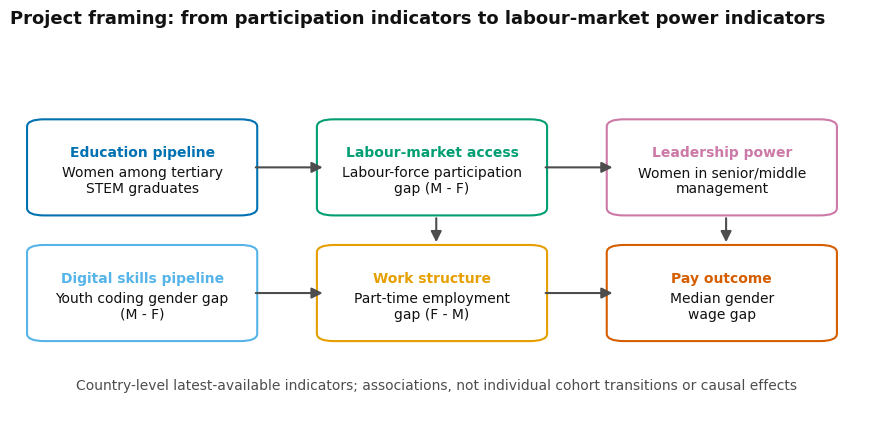

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.set_axis_off()

box_specs = [
    {
        "xy": (0.04, 0.56),
        "title": "Education pipeline",
        "body": "Women among tertiary\nSTEM graduates",
        "color": COLORS["blue"],
    },
    {
        "xy": (0.04, 0.22),
        "title": "Digital skills pipeline",
        "body": "Youth coding gender gap\n(M - F)",
        "color": COLORS["sky"],
    },
    {
        "xy": (0.38, 0.56),
        "title": "Labour-market access",
        "body": "Labour-force participation\ngap (M - F)",
        "color": COLORS["green"],
    },
    {
        "xy": (0.38, 0.22),
        "title": "Work structure",
        "body": "Part-time employment\ngap (F - M)",
        "color": COLORS["orange"],
    },
    {
        "xy": (0.72, 0.56),
        "title": "Leadership power",
        "body": "Women in senior/middle\nmanagement",
        "color": COLORS["purple"],
    },
    {
        "xy": (0.72, 0.22),
        "title": "Pay outcome",
        "body": "Median gender\nwage gap",
        "color": COLORS["vermillion"],
    },
]

for spec in box_specs:
    x, y = spec["xy"]
    box = FancyBboxPatch(
        (x, y),
        0.23,
        0.22,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.5,
        edgecolor=spec["color"],
        facecolor=COLORS["white"],
    )
    ax.add_patch(box)
    ax.text(x + 0.115, y + 0.15, spec["title"], ha="center", va="center", weight="bold", color=spec["color"])
    ax.text(x + 0.115, y + 0.075, spec["body"], ha="center", va="center", color=COLORS["black"])

arrow_specs = [
    ((0.285, 0.67), (0.37, 0.67)),
    ((0.285, 0.33), (0.37, 0.33)),
    ((0.625, 0.67), (0.71, 0.67)),
    ((0.625, 0.33), (0.71, 0.33)),
    ((0.50, 0.54), (0.50, 0.46)),
    ((0.84, 0.54), (0.84, 0.46)),
]

for start, end in arrow_specs:
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color=COLORS["dark_grey"],
        )
    )

ax.text(
    0.5,
    0.08,
    "Country-level latest-available indicators; associations, not individual cohort transitions or causal effects",
    ha="center",
    va="center",
    color=COLORS["dark_grey"],
    fontsize=10,
)

ax.set_title("Project framing: from participation indicators to labour-market power indicators", loc="left", pad=16)

save_figure(fig, "fig01_conceptual_framework.png")
plt.show()
plt.close(fig)

## Figure 2. Indicator coverage

This figure supports the data curation section by showing how many OECD member countries are available for each indicator.

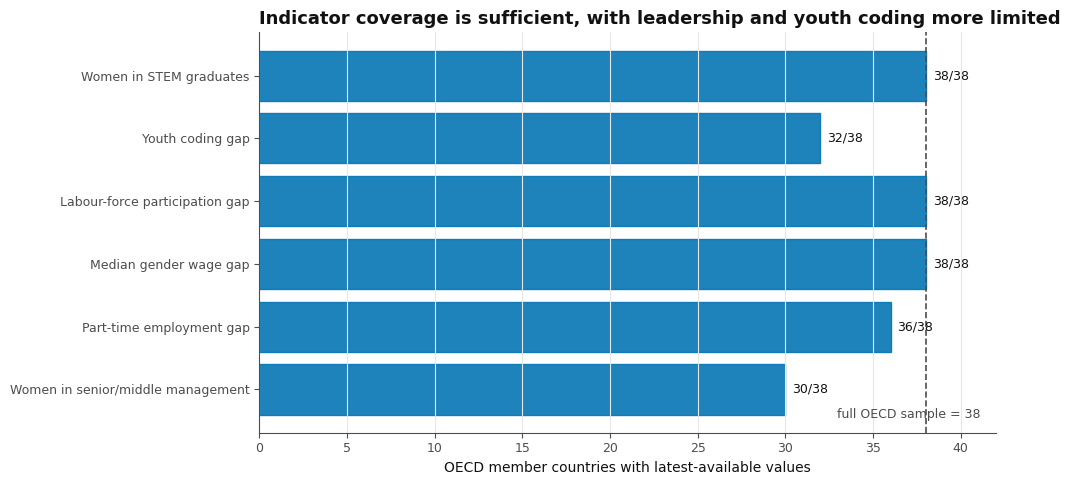

In [7]:
coverage = indicator_coverage.merge(
    data_dict[["name", "source"]],
    left_on="source_key",
    right_on="source",
    how="left",
)
coverage["name"] = coverage["name"].fillna(coverage["indicator"])
coverage["label"] = coverage["name"].map(short_indicator_labels).fillna(coverage["name"])
coverage["order"] = coverage["name"].map({name: i for i, name in enumerate(indicator_order)})
coverage = coverage.sort_values("order", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.2))

ax.barh(
    coverage["label"],
    coverage["countries_oecd_members"],
    color=COLORS["blue"],
    edgecolor=COLORS["blue"],
    alpha=0.88,
)
ax.axvline(38, color=COLORS["dark_grey"], linewidth=1.2, linestyle="--")

for y, value in enumerate(coverage["countries_oecd_members"]):
    ax.text(value + 0.4, y, f"{int(value)}/38", va="center", ha="left", color=COLORS["black"], fontsize=9)

ax.set_xlim(0, 42)
ax.set_xlabel("OECD member countries with latest-available values")
ax.set_ylabel("")
ax.set_title("Indicator coverage is sufficient, with leadership and youth coding more limited", loc="left")
ax.text(
    0.98,
    0.03,
    "full OECD sample = 38",
    transform=ax.transAxes,
    color=COLORS["dark_grey"],
    fontsize=9,
    ha="right",
    va="bottom",
)
clean_axes(ax, grid_axis="x")

save_figure(fig, "fig02_indicator_coverage_oecd.png")
plt.show()
plt.close(fig)

## Figure 3. Estonia benchmark against the OECD median

This figure uses a direction-adjusted difference from the OECD median. Values to the right mean Estonia is more favourable on that indicator; values to the left mean Estonia is less favourable.

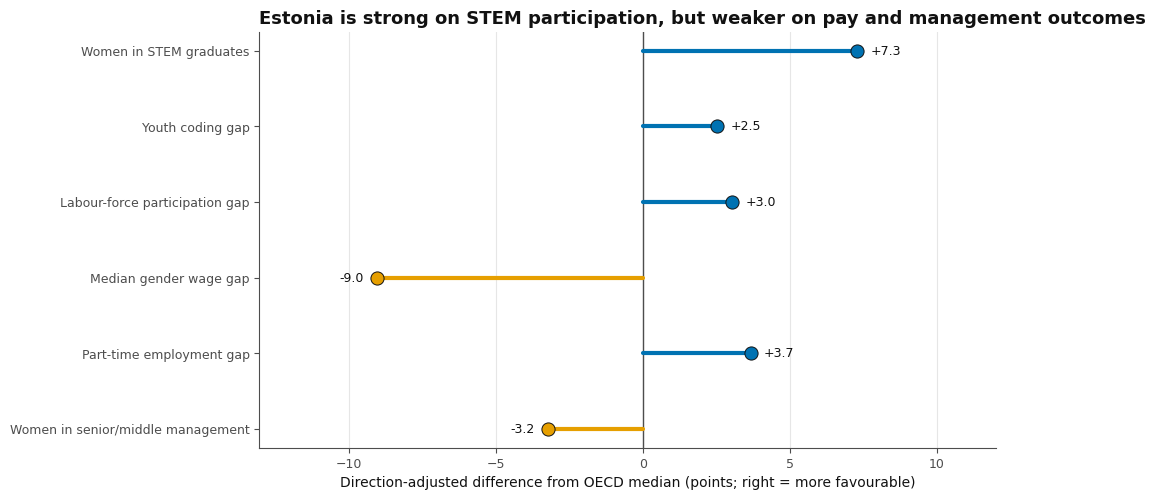

In [8]:
benchmark = estonia_benchmark.copy()
benchmark["label"] = benchmark["variable"].map(short_indicator_labels)
benchmark["order"] = benchmark["variable"].map({name: i for i, name in enumerate(indicator_order)})
benchmark["higher_is_better"] = benchmark["directional_rank_label"].eq("rank_high_to_low")
benchmark["direction_adjusted_difference"] = np.where(
    benchmark["higher_is_better"],
    benchmark["difference_from_oecd_median"],
    -benchmark["difference_from_oecd_median"],
)
benchmark = benchmark.sort_values("order", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 5.4))
y = np.arange(len(benchmark))
values = benchmark["direction_adjusted_difference"].to_numpy()
colors = np.where(values >= 0, COLORS["blue"], COLORS["orange"])

ax.axvline(0, color=COLORS["dark_grey"], linewidth=1)
for yi, value, color in zip(y, values, colors):
    ax.plot([0, value], [yi, yi], color=color, linewidth=3, solid_capstyle="round")
    ax.scatter(value, yi, s=90, color=color, edgecolor=COLORS["black"], linewidth=0.7, zorder=3)
    ax.text(
        value + (0.45 if value >= 0 else -0.45),
        yi,
        f"{value:+.1f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=9,
        color=COLORS["black"],
    )

ax.set_yticks(y)
ax.set_yticklabels(benchmark["label"])
ax.set_xlabel("Direction-adjusted difference from OECD median (points; right = more favourable)")
ax.set_ylabel("")
ax.set_title("Estonia is strong on STEM participation, but weaker on pay and management outcomes", loc="left")
ax.set_xlim(min(values.min() - 4, -12), max(values.max() + 4, 12))
clean_axes(ax, grid_axis="x")

save_figure(fig, "fig03_estonia_vs_oecd_median_direction_adjusted.png")
plt.show()
plt.close(fig)

## Figure 4. OECD distributions with Estonia highlighted

This figure provides distribution context for the six core indicators. Grey points are OECD member countries; the orange diamond is Estonia; the black tick marks the OECD median.

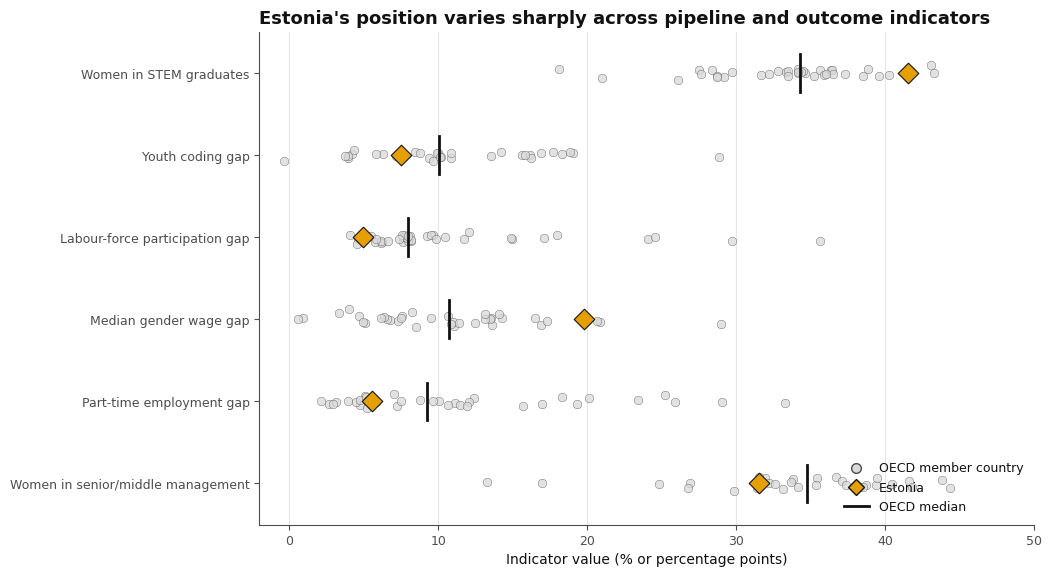

In [9]:
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(10, 6.4))
y_positions = np.arange(len(indicator_order))[::-1]

for pos, variable in zip(y_positions, indicator_order):
    values = df_main[["REF_AREA", variable]].dropna()
    jitter = rng.normal(0, 0.045, size=len(values))
    ax.scatter(
        values[variable],
        np.full(len(values), pos) + jitter,
        s=38,
        color=COLORS["light_grey"],
        edgecolor=COLORS["dark_grey"],
        linewidth=0.35,
        alpha=0.75,
        zorder=2,
    )

    median_value = values[variable].median()
    ax.plot(
        [median_value, median_value],
        [pos - 0.23, pos + 0.23],
        color=COLORS["black"],
        linewidth=2.0,
        zorder=3,
    )

    estonia_value = values.loc[values["REF_AREA"].eq("EST"), variable]
    if not estonia_value.empty:
        ax.scatter(
            estonia_value.iloc[0],
            pos,
            s=110,
            marker="D",
            color=COLORS["orange"],
            edgecolor=COLORS["black"],
            linewidth=0.8,
            zorder=4,
        )

ax.set_yticks(y_positions)
ax.set_yticklabels([short_indicator_labels[v] for v in indicator_order])
ax.set_xlabel("Indicator value (% or percentage points)")
ax.set_ylabel("")
ax.set_title("Estonia's position varies sharply across pipeline and outcome indicators", loc="left")
ax.set_xlim(-2, 50)
clean_axes(ax, grid_axis="x")

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=COLORS["light_grey"], markeredgecolor=COLORS["dark_grey"], markersize=7, label="OECD member country"),
    plt.Line2D([0], [0], marker="D", color="none", markerfacecolor=COLORS["orange"], markeredgecolor=COLORS["black"], markersize=8, label="Estonia"),
    plt.Line2D([0], [0], color=COLORS["black"], linewidth=2, label="OECD median"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False)

save_figure(fig, "fig04_oecd_distributions_estonia_highlight.png")
plt.show()
plt.close(fig)

## Figure 5. Hypothesis results summary

This figure summarizes Pearson correlations for the four hypothesis tests. Confidence intervals use Fisher's z approximation.

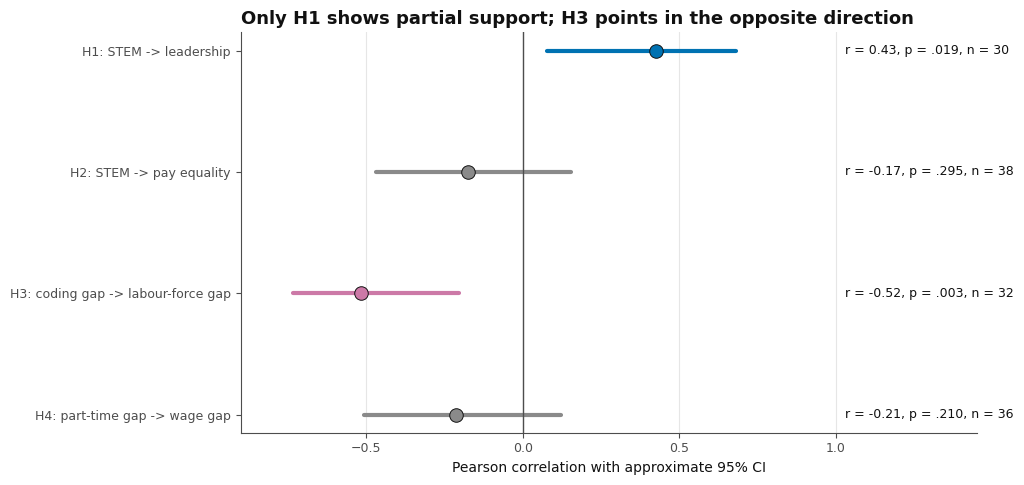

In [10]:
results = hypothesis_results.copy()
results["hypothesis_label"] = results["hypothesis_id"].map(hypothesis_labels)
results[["ci_low", "ci_high"]] = results.apply(
    lambda row: pd.Series(pearson_ci(row["pearson_r"], row["n"])),
    axis=1,
)
results["order"] = results["hypothesis_id"].str.extract(r"(\d+)").astype(int)
results = results.sort_values("order", ascending=False)

status_colors = {
    "H1": COLORS["blue"],
    "H2": COLORS["mid_grey"],
    "H3": COLORS["purple"],
    "H4": COLORS["mid_grey"],
}

fig, ax = plt.subplots(figsize=(9.5, 5.2))
y = np.arange(len(results))

for yi, row in zip(y, results.itertuples()):
    color = status_colors.get(row.hypothesis_id, COLORS["mid_grey"])
    ax.plot([row.ci_low, row.ci_high], [yi, yi], color=color, linewidth=3, solid_capstyle="round")
    ax.scatter(row.pearson_r, yi, s=95, color=color, edgecolor=COLORS["black"], linewidth=0.7, zorder=3)
    ax.text(
        1.03,
        yi,
        f"r = {row.pearson_r:.2f}, {format_p_value(row.pearson_p)}, n = {int(row.n)}",
        va="center",
        ha="left",
        fontsize=9,
        color=COLORS["black"],
    )

ax.axvline(0, color=COLORS["dark_grey"], linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(results["hypothesis_label"])
ax.set_xlim(-0.9, 1.45)
ax.set_xlabel("Pearson correlation with approximate 95% CI")
ax.set_ylabel("")
ax.set_title("Only H1 shows partial support; H3 points in the opposite direction", loc="left")
clean_axes(ax, grid_axis="x")

save_figure(fig, "fig05_hypothesis_results_pearson_summary.png")
plt.show()
plt.close(fig)

In [11]:
def plot_relationship(
    ax,
    data,
    x,
    y,
    *,
    result_row,
    x_label=None,
    y_label=None,
    title=None,
    highlights=None,
    annotate=None,
    high_year_gap_threshold=None,
):
    # Draw a report-style scatterplot with a linear fit and selected country highlights.
    plot_data = data.dropna(subset=[x, y]).copy()
    highlights = highlights or {}
    annotate = annotate or []

    if high_year_gap_threshold is not None and "pairwise_year_gap" in plot_data:
        normal = plot_data[plot_data["pairwise_year_gap"] <= high_year_gap_threshold]
        high_gap = plot_data[plot_data["pairwise_year_gap"] > high_year_gap_threshold]
        ax.scatter(
            normal[x],
            normal[y],
            s=44,
            color=COLORS["light_grey"],
            edgecolor=COLORS["dark_grey"],
            linewidth=0.35,
            alpha=0.8,
            label=f"Year gap <= {high_year_gap_threshold}",
        )
        ax.scatter(
            high_gap[x],
            high_gap[y],
            s=58,
            facecolor=COLORS["white"],
            edgecolor=COLORS["purple"],
            linewidth=1.5,
            alpha=0.95,
            label=f"Year gap > {high_year_gap_threshold}",
        )
    else:
        ax.scatter(
            plot_data[x],
            plot_data[y],
            s=44,
            color=COLORS["light_grey"],
            edgecolor=COLORS["dark_grey"],
            linewidth=0.35,
            alpha=0.8,
        )

    if len(plot_data) >= 3:
        slope, intercept, *_ = stats.linregress(plot_data[x], plot_data[y])
        x_grid = np.linspace(plot_data[x].min(), plot_data[x].max(), 100)
        y_grid = intercept + slope * x_grid
        ax.plot(x_grid, y_grid, color=COLORS["blue"], linewidth=2.0, alpha=0.95)

    for country, style in highlights.items():
        row = plot_data[plot_data["REF_AREA"].eq(country)]
        if row.empty:
            continue
        ax.scatter(
            row[x],
            row[y],
            s=120,
            marker=style.get("marker", "D"),
            color=style.get("color", COLORS["orange"]),
            edgecolor=COLORS["black"],
            linewidth=0.9,
            zorder=4,
            label=style.get("label", country),
        )

    for item in annotate:
        if isinstance(item, str):
            country = item
            dx, dy = 0.5, 0.5
        else:
            country, dx, dy = item
        row = plot_data[plot_data["REF_AREA"].eq(country)]
        if row.empty:
            continue
        ax.annotate(
            country,
            (row[x].iloc[0], row[y].iloc[0]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            weight="bold" if country in highlights else "normal",
            color=COLORS["black"],
        )

    note = f"r = {result_row['pearson_r']:.2f}, {format_p_value(result_row['pearson_p'])}, n = {int(result_row['n'])}"
    ax.text(
        0.02,
        0.98,
        note,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=COLORS["white"], edgecolor=COLORS["light_grey"]),
    )

    ax.set_xlabel(x_label or axis_labels.get(x, x))
    ax.set_ylabel(y_label or axis_labels.get(y, y))
    if title:
        ax.set_title(title, loc="left")
    clean_axes(ax, grid_axis="both")
    return ax

## Figure 6. H1 relationship with Estonia and Japan highlighted

This figure is useful for the report because H1 receives partial support but is sensitive to influential observations, especially Japan.

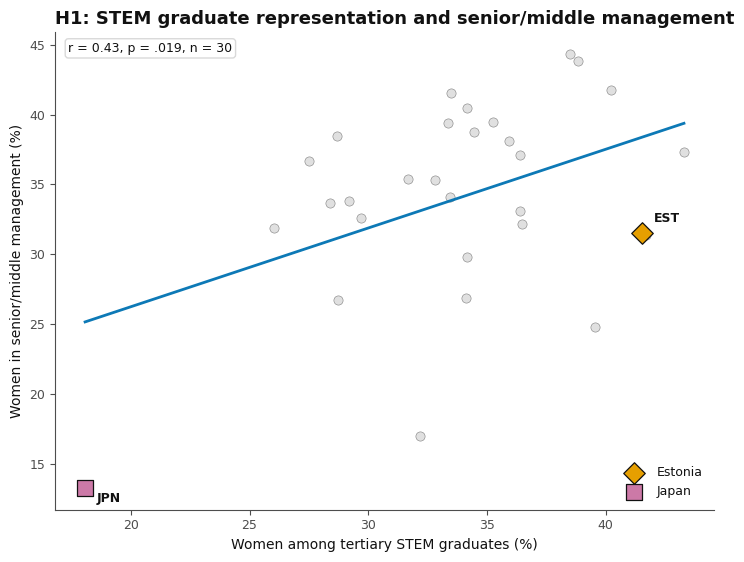

In [12]:
h1_result = hypothesis_results.loc[hypothesis_results["hypothesis_id"].eq("H1")].iloc[0]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
plot_relationship(
    ax,
    h1_sample,
    "stem_women_share",
    "women_senior_middle_mgmt_share",
    result_row=h1_result,
    title="H1: STEM graduate representation and senior/middle management",
    highlights={
        "EST": {"label": "Estonia", "color": COLORS["orange"], "marker": "D"},
        "JPN": {"label": "Japan", "color": COLORS["purple"], "marker": "s"},
    },
    annotate=[("EST", 8, 8), ("JPN", 8, -10)],
)
ax.legend(frameon=False, loc="lower right")

save_figure(fig, "fig06_h1_stem_to_management_estonia_japan.png")
plt.show()
plt.close(fig)

## Figure 7. Pay-related hypotheses

These small multiples compare H2 and H4. They show why the median gender wage gap indicator is not explained by a simple bivariate relationship with either STEM graduate share or the part-time employment gap.

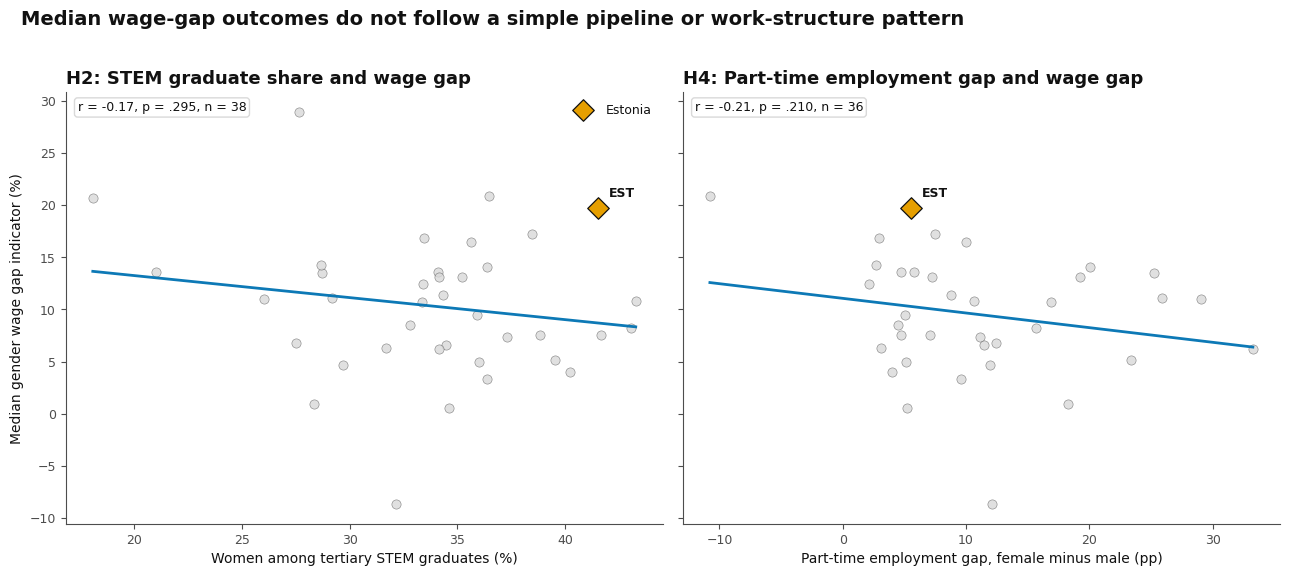

In [13]:
h2_result = hypothesis_results.loc[hypothesis_results["hypothesis_id"].eq("H2")].iloc[0]
h4_result = hypothesis_results.loc[hypothesis_results["hypothesis_id"].eq("H4")].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)

plot_relationship(
    axes[0],
    h2_sample,
    "stem_women_share",
    "gender_wage_gap_median",
    result_row=h2_result,
    title="H2: STEM graduate share and wage gap",
    highlights={"EST": {"label": "Estonia", "color": COLORS["orange"], "marker": "D"}},
    annotate=[("EST", 8, 8)],
)

plot_relationship(
    axes[1],
    h4_sample,
    "part_time_employment_gap_F_minus_M",
    "gender_wage_gap_median",
    result_row=h4_result,
    title="H4: Part-time employment gap and wage gap",
    highlights={"EST": {"label": "Estonia", "color": COLORS["orange"], "marker": "D"}},
    annotate=[("EST", 8, 8)],
)
axes[1].set_ylabel("")
axes[0].legend(frameon=False, loc="upper right")

fig.suptitle("Median wage-gap outcomes do not follow a simple pipeline or work-structure pattern", x=0.02, y=1.02, ha="left", fontsize=14, weight="bold")
fig.tight_layout()

save_figure(fig, "fig07_h2_h4_pay_related_scatterplots.png")
plt.show()
plt.close(fig)

## Figure 8. H3 exploratory relationship

H3 is treated as exploratory because the indicators refer to different age groups and have the largest pairwise year-alignment caveat.

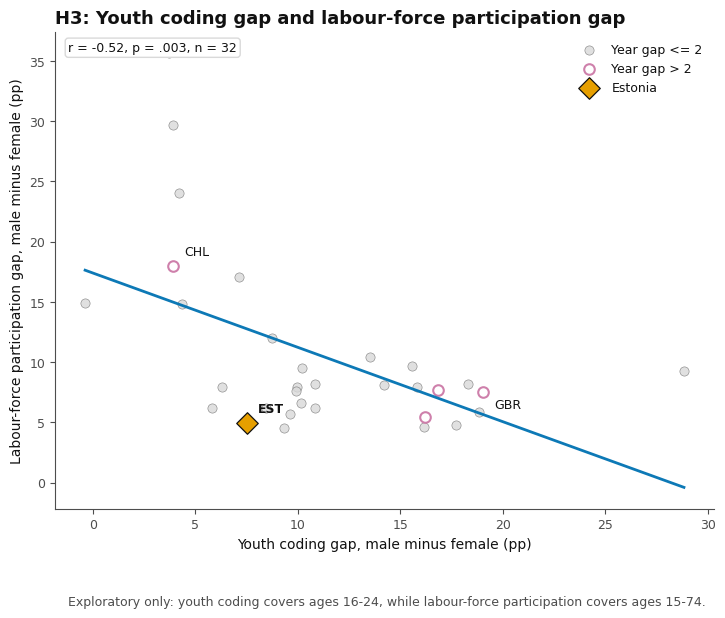

In [14]:
h3_result = hypothesis_results.loc[hypothesis_results["hypothesis_id"].eq("H3")].iloc[0]

fig, ax = plt.subplots(figsize=(8.5, 6.2))
plot_relationship(
    ax,
    h3_sample,
    "coding_gap_youth_M_minus_F",
    "labour_force_participation_gap_M_minus_F",
    result_row=h3_result,
    title="H3: Youth coding gap and labour-force participation gap",
    highlights={"EST": {"label": "Estonia", "color": COLORS["orange"], "marker": "D"}},
    annotate=[("EST", 8, 8), ("CHL", 8, 8), ("GBR", 8, -12)],
    high_year_gap_threshold=2,
)
ax.legend(frameon=False, loc="upper right")

ax.text(
    0.02,
    -0.18,
    "Exploratory only: youth coding covers ages 16-24, while labour-force participation covers ages 15-74.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color=COLORS["dark_grey"],
)

save_figure(fig, "fig08_h3_coding_gap_lfp_gap_exploratory.png")
plt.show()
plt.close(fig)

## Table 1. Data overview and indicator definitions

This table is a compact reference for the report's data curation, variable definitions, units, coverage, and caveats.

In [15]:
layer_labels = {
    "education_pipeline": "Education pipeline",
    "digital_skills_pipeline": "Digital skills pipeline",
    "work_access": "Labour-market access",
    "pay_outcome": "Pay outcome",
    "work_structure_care": "Work structure / care",
    "leadership_proxy": "Leadership proxy",
}

unit_labels = {
    "percent": "%",
    "percentage points": "percentage points",
}

coverage_lookup = indicator_coverage.set_index("source_key")
table1_rows = []

for variable in indicator_order:
    meta = data_dict.loc[data_dict["name"].eq(variable)].iloc[0]
    source_key = meta["source"]
    coverage_row = coverage_lookup.loc[source_key]
    year_col = f"{variable}_year"
    latest_years = df_main.loc[df_main[variable].notna(), year_col].dropna()

    if latest_years.empty:
        latest_year_label = "Not available"
    else:
        year_min = int(latest_years.min())
        year_max = int(latest_years.max())
        latest_year_label = str(year_min) if year_min == year_max else f"{year_min}-{year_max}"

    table1_rows.append({
        "Indicator": short_indicator_labels[variable],
        "Conceptual layer": layer_labels.get(meta["layer"], meta["layer"]),
        "Unit": unit_labels.get(meta["final_unit"], meta["final_unit"]),
        "Direction": meta["direction"],
        "Coverage": f"{int(coverage_row['countries_oecd_members'])}/38 OECD members",
        "Latest years": latest_year_label,
        "Main limitation": meta["limitations"],
    })

table1_indicator_definitions = pd.DataFrame(table1_rows)
save_table(table1_indicator_definitions, "table01_indicator_definitions.csv")
table1_indicator_definitions

,Indicator,Conceptual layer,Unit,Direction,Coverage,Latest years,Main limitation
0,Women in STEM graduates,Education pipeline,%,Higher = more women represented among tertiary...,38/38 OECD members,2023-2024,Captures graduation output in selected STEM fi...
1,Youth coding gap,Digital skills pipeline,percentage points,Higher = larger male advantage in youth coding...,32/38 OECD members,2017-2025,Measures coding activity among 16-24-year-olds...
2,Labour-force participation gap,Labour-market access,percentage points,Higher = larger male advantage in labour-force...,38/38 OECD members,2025,Measures labour-force participation for ages 1...
3,Median gender wage gap,Pay outcome,%,Higher = larger wage inequality / worse pay ou...,38/38 OECD members,2022-2024,Unadjusted wage gap indicator. Should not be i...
4,Part-time employment gap,Work structure / care,percentage points,Higher = women are more concentrated in part-t...,36/38 OECD members,2025,Measures the gender difference in part-time em...
5,Women in senior/middle management,Leadership proxy,%,Higher = more women represented in senior and ...,30/38 OECD members,2022-2024,Used as a proxy for leadership and labour-mark...


## Table 2. Hypothesis results

This table provides a transparent numerical reference for the hypothesis-testing section. Figure 5 gives the visual summary; this table keeps exact test details together.

In [16]:
summary_lookup = hypothesis_summary.set_index("hypothesis_id")["result_assessment"].to_dict()

table2 = hypothesis_results.copy()
table2["Hypothesis"] = table2.apply(
    lambda row: f"{row['hypothesis_id']} - {row['hypothesis_name']}",
    axis=1,
)
table2["Expected direction"] = table2["expected_direction"]
table2["Pearson r / raw p"] = table2.apply(
    lambda row: f"r = {row['pearson_r']:.2f}; {format_p_value(row['pearson_p'])}",
    axis=1,
)
table2["Holm-adjusted p"] = table2.apply(
    lambda row: (
        format_p_value(row["pearson_p_holm_primary"])
        if pd.notna(row.get("pearson_p_holm_primary", np.nan))
        else "not applied"
    ),
    axis=1,
)
table2["Spearman"] = table2.apply(
    lambda row: f"rho = {row['spearman_rho']:.2f}; {format_p_value(row['spearman_p'])}",
    axis=1,
)
table2["OLS slope CI"] = table2.apply(
    lambda row: f"{row['ols_slope']:.2f} [{row['ols_slope_ci_low']:.2f}, {row['ols_slope_ci_high']:.2f}]",
    axis=1,
)
table2["Assessment"] = table2["hypothesis_id"].map(summary_lookup)

table2_hypothesis_results = table2[
    [
        "Hypothesis",
        "Expected direction",
        "n",
        "Pearson r / raw p",
        "Holm-adjusted p",
        "Spearman",
        "OLS slope CI",
        "Assessment",
    ]
].copy()

save_table(table2_hypothesis_results, "table02_hypothesis_results.csv")
table2_hypothesis_results

,Hypothesis,Expected direction,n,Pearson r / raw p,Holm-adjusted p,Spearman,OLS slope CI,Assessment
0,H1 - STEM-to-leadership conversion,positive,30,r = 0.43; p = .019,p = .037,rho = 0.25; p = .188,"0.56 [0.10, 1.03]",partial support
1,H2 - STEM-to-pay equality,negative,38,r = -0.17; p = .295,p = .295,rho = -0.12; p = .468,"-0.21 [-0.61, 0.19]",not supported / inconclusive
2,H3 - Digital-skills gap and labour-market part...,positive,32,r = -0.52; p = .003,not applied,rho = -0.46; p = .008,"-0.62 [-1.00, -0.23]",expected direction not supported
3,H4 - Work-structure bottleneck,positive,36,r = -0.21; p = .210,not applied,rho = -0.21; p = .214,"-0.14 [-0.36, 0.08]",not supported


## Table 3. Recommendation action matrix

This table links findings to practical, evidence-informed recommendations. It should be read as an action and monitoring plan, not as causal proof that the proposed actions will eliminate gender inequality.

In [17]:
table3_recommendation_action_matrix = pd.DataFrame([
    {
        "Finding": "Estonia combines high women's representation among tertiary STEM graduates with a high median gender wage gap indicator and below-median women representation in senior/middle management.",
        "Recommendation": "Shift from pipeline-only monitoring to conversion-layer monitoring from STEM education into employment, retention, pay, and leadership outcomes.",
        "Target stakeholder": "Estonia-facing gender-equality stakeholders; ministries; statistical agencies; universities; employer associations.",
        "Metric to monitor": "STEM graduates by gender; STEM employment entry; retention in STEM-intensive sectors; senior/middle management share; gender wage gap by sector and occupation.",
        "Limitation / risk": "Current OECD data are country-level and latest-available; stronger monitoring needs cohort, sector, occupation, and firm-level data.",
    },
    {
        "Finding": "H1 shows partial support for a positive STEM-to-leadership association, but the result is sensitive to influential observations, especially Japan.",
        "Recommendation": "Pilot and evaluate advancement-focused interventions such as sponsorship, promotion transparency, and leadership pipeline programs in STEM-intensive sectors.",
        "Target stakeholder": "Employers; employer associations; professional networks; public-sector equality programs.",
        "Metric to monitor": "Promotion rates by gender; time to promotion; retention after first STEM job; share of women in senior/middle management; participation in sponsorship programs.",
        "Limitation / risk": "Mentoring or sponsorship alone may not address structural promotion barriers unless paired with promotion and pay-system audits.",
    },
    {
        "Finding": "H2 is not supported: higher women's STEM graduate share is not strongly associated with lower median gender wage gap indicator values across OECD countries.",
        "Recommendation": "Prioritize pay-transparency tools and regular gender pay audits instead of assuming that STEM education gains will automatically reduce pay inequality.",
        "Target stakeholder": "Government equality bodies; labour-market regulators; employers; HR and compensation teams.",
        "Metric to monitor": "Unadjusted and adjusted gender wage gaps; pay bands; bonus gaps; occupational sorting; firm-level wage gaps in high-wage and STEM-intensive sectors.",
        "Limitation / risk": "The OECD wage-gap indicator is broad; pay audits require more detailed firm, occupation, hours, tenure, and role-level data with privacy safeguards.",
    },
    {
        "Finding": "H3 is exploratory and points in the opposite direction: youth coding gaps and overall labour-force participation gaps do not align as expected.",
        "Recommendation": "Treat youth digital participation as a separate early-pipeline measure and track whether it converts into ICT/STEM study, internships, and first jobs.",
        "Target stakeholder": "Education ministries; digital-skills programs; universities; career services; youth employment initiatives.",
        "Metric to monitor": "Coding participation by gender; ICT/STEM enrolment; internships; first job in ICT/STEM; transition rates from digital skills programs into employment.",
        "Limitation / risk": "The indicators refer to different age groups and years; this result should not be interpreted as a causal inverse relationship.",
    },
    {
        "Finding": "H4 is not supported as a simple country-level bivariate association between the part-time employment gap and the median gender wage gap indicator.",
        "Recommendation": "Use a broader work-structure monitoring set that includes care responsibilities, parental leave uptake, career breaks, job quality, and progression after leave.",
        "Target stakeholder": "Social policy stakeholders; employers; labour-market researchers; family-policy agencies.",
        "Metric to monitor": "Part-time employment by gender; parental leave uptake by gender; childcare access; career-break duration; return-to-work outcomes; post-leave promotion and pay progression.",
        "Limitation / risk": "Part-time employment incidence is not a direct measure of care burden, job quality, discrimination, or occupation-level wage penalties.",
    },
])

save_table(table3_recommendation_action_matrix, "table03_recommendation_action_matrix.csv")
table3_recommendation_action_matrix

,Finding,Recommendation,Target stakeholder,Metric to monitor,Limitation / risk
0,Estonia combines high women's representation a...,Shift from pipeline-only monitoring to convers...,Estonia-facing gender-equality stakeholders; m...,STEM graduates by gender; STEM employment entr...,Current OECD data are country-level and latest...
1,H1 shows partial support for a positive STEM-t...,Pilot and evaluate advancement-focused interve...,Employers; employer associations; professional...,Promotion rates by gender; time to promotion; ...,Mentoring or sponsorship alone may not address...
2,H2 is not supported: higher women's STEM gradu...,Prioritize pay-transparency tools and regular ...,Government equality bodies; labour-market regu...,Unadjusted and adjusted gender wage gaps; pay ...,The OECD wage-gap indicator is broad; pay audi...
3,H3 is exploratory and points in the opposite d...,Treat youth digital participation as a separat...,Education ministries; digital-skills programs;...,Coding participation by gender; ICT/STEM enrol...,The indicators refer to different age groups a...
4,H4 is not supported as a simple country-level ...,Use a broader work-structure monitoring set th...,Social policy stakeholders; employers; labour-...,Part-time employment by gender; parental leave...,Part-time employment incidence is not a direct...


## Export checklist

The final cell lists all figure and table files created by this notebook.

In [18]:
pd.DataFrame({
    "artifact_type": ["figure"] * len(saved_figures) + ["table"] * len(saved_tables),
    "artifact_path": [str(path) for path in saved_figures] + [str(path) for path in saved_tables],
})

,artifact_type,artifact_path
0,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
1,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
2,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
3,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
4,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
5,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
6,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
7,figure,/Users/avr/Jupiter/Gender Inequality Report - ...
8,table,/Users/avr/Jupiter/Gender Inequality Report - ...
9,table,/Users/avr/Jupiter/Gender Inequality Report - ...
